In [81]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 - Performance Analysis of artificial graphs - With different subsets of features

In [84]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
        G = nx.node_link_graph(data)
    
    print(f"Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    return G

def add_ground_truth_groups(df, G):
    true_partition = dict(nx.get_node_attributes(G, 'block'))
    
    if not true_partition:
        print("Dictionnaire vide ! Vérifie si 'block' existe dans G.nodes(data=True)")
        return df

    df['group_u'] = df['u'].map(true_partition)
    df['group_v'] = df['v'].map(true_partition)
    
    df['group_u'] = df['group_u'].fillna(-1).astype(int)
    df['group_v'] = df['group_v'].fillna(-1).astype(int)
    df['same_group'] = (df['group_u'] == df['group_v']).astype(int)
    
    return df

def shuffle_ground_truth(df):
    """
    Crée des versions mélangées des colonnes de groupes.
    """
    df_shuffled = df.copy()
    # On récupère tous les IDs uniques présents et on les mélange
    unique_groups = df_shuffled['group_u'].unique()
    shuffled_map = dict(zip(unique_groups, np.random.permutation(unique_groups)))
    
    # On applique le mapping pour que la structure logique "same_group" disparaisse
    df_shuffled['group_u_shuffled'] = df_shuffled['group_u'].map(shuffled_map)
    df_shuffled['group_v_shuffled'] = df_shuffled['group_v'].map(shuffled_map)
    # On recalcule un same_group qui ne veut plus rien dire
    df_shuffled['same_group_shuffled'] = (df_shuffled['group_u_shuffled'] == df_shuffled['group_v_shuffled']).astype(int)
    
    return df_shuffled

In [94]:
# Groupes de features analysés
features_structure = ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v']
features_commu_inferee = ['louvain_v', 'same_louvain', 'infomap_u', 'infomap_v', 'same_infomap', 'sbm_community_u', 'sbm_community_v', 'same_sbm_community']
features_commu_inferee_same_group_only = ['same_louvain', 'same_infomap', 'same_sbm_community']
features_embeddings = ['n2v_p2_q0.5_cosine', 'n2v_p2_q0.5_dist', 'n2v_p1_q1_cosine', 'n2v_p1_q1_dist']
features_ground_truth = ['group_u', 'group_v','same_group']
features_ground_truth_same_group_only = ['same_group']
features_gt_shuffled = ['group_u_shuffled', 'group_v_shuffled', 'same_group_shuffled']

experiments = {
    "Ground_Truth_Only_SG" : features_ground_truth_same_group_only,
    "Ground_Truth_Only": features_ground_truth,
    "Ground_Truth_Shuffled": features_gt_shuffled,
    "Structure_Only": features_structure,
    "Embeddings_Only": features_embeddings,
    "Inferred_Commu only": features_commu_inferee,
    "Inferred_Commu_sg_only": features_commu_inferee_same_group_only,
    "Embeddings + Inferred_Commu": features_embeddings + features_commu_inferee,
    #"Structure + Inferred_Commu": features_structure + features_commu_inferee,
    #"Structure + Embeddings": features_structure + features_embeddings,
    "Full_with_Embeddings": features_structure + features_commu_inferee + features_embeddings
}

all_results = []

for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    # 1. Chargement du dataset (Parquet) et du Graphe (JSON pour les blocs)
    dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
    G_json = load_json(f"graph_library/{G_name}.json")

    if i == 0 : 
        print(dataset.columns)
    
    # 2. Injection de la vérité terrain
    dataset = add_ground_truth_groups(dataset, G_json)
    dataset = shuffle_ground_truth(dataset)
    
    # 3. Lancement des tests
    for exp_name, feat_list in experiments.items():
        stats_df, model, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=feat_list)
        
        all_results.append({
            "Ratio_SBM": i,
            "Experiment": exp_name,
            "AUC-PR": stats_df["AUC-PR"].iloc[0],
            "AP": stats_df["AP"].iloc[0],
            'AUC-ROC': stats_df["AUC-ROC"].iloc[0],
            "F1-Score": stats_df["F1-Score"].iloc[0],
        })

# Recap final
df_compare = pd.DataFrame(all_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "comparaison_finale_structure_vs_gt.csv")
df_compare.to_csv(output_path, index=False)
print(f"✅ Succès ! Fichier sauvegardé dans : {output_path}")

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 38500 lignes, 29 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Graphe chargé : 1000 nœuds et 3500 liens.
Index(['u', 'v', 'target', 'cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v',
       'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'louvain_u',
       'louvain_v', 'same_louvain', 'infomap_u', 'infomap_v', 

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(



 RÉSULTATS
[{'F1-Score': 0.0, 'AUC-ROC': 0.5014724609996816, 'AP': 0.09383505383505385, 'AUC-PR': 0.11332778332778334}]

 RÉSULTATS
[{'F1-Score': 0.0, 'AUC-ROC': 0.7501350087551735, 'AP': 0.172817938299046, 'AUC-PR': 0.17209376507951507}]

 RÉSULTATS
[{'F1-Score': 0.0, 'AUC-ROC': 0.7135543019738937, 'AP': 0.16554644403363228, 'AUC-PR': 0.1649137946493045}]

 RÉSULTATS
[{'F1-Score': 0.9640387275242047, 'AUC-ROC': 0.9993856454950654, 'AP': 0.9949239160894505, 'AUC-PR': 0.9949217667625486}]

 RÉSULTATS
[{'F1-Score': 0.9577854671280277, 'AUC-ROC': 0.9985038602355937, 'AP': 0.9819129824374955, 'AUC-PR': 0.9821799309570733}]

 RÉSULTATS
[{'F1-Score': 0.8788300835654597, 'AUC-ROC': 0.9874762217446673, 'AP': 0.8940218408253331, 'AUC-PR': 0.8948704561339216}]

 RÉSULTATS
[{'F1-Score': 0.8783592644978784, 'AUC-ROC': 0.971176376950016, 'AP': 0.8483902908938143, 'AUC-PR': 0.908909399813457}]

 RÉSULTATS
[{'F1-Score': 0.9565217391304348, 'AUC-ROC': 0.9985028653295129, 'AP': 0.9815853726626236, 'AU

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Graphe chargé : 1000 nœuds et 3500 liens.

 RÉSULTATS
[{'F1-Score': 0.0, 'AUC-ROC': 0.5275250716332378, 'AP': 0.11665718302316241, 'AUC-PR': 0.3070399317177668}]

 RÉSULTATS
[{'F1-Score': 0.021768707482993196, 'AUC-ROC': 0.7477881248010187, 'AP': 0.1994111422359292, 'AUC-PR': 0.1989657117134117}]

 RÉSULTATS
[{'F1-Score': 0.021768707482993196, 'AUC-ROC': 0.7183060729067176, 'AP': 0.191604566196292, 'AUC-PR': 0.1902301085273209}]

 RÉSULTATS
[{'F1-Score': 0.9658536585365853, 'AUC-ROC': 0.9970046362623368, 'AP': 0.9902071637051032, 'AUC-PR': 0.9902036238709161}]

 RÉSULTATS
[{'F1-Score': 0.9574912891986063, 'AUC-ROC': 0.9943849490608087, 'AP': 0.9801473027927535, 'AUC-PR': 0.9801423955905443}]

 RÉSULTATS
[{'F1-Score': 0.8618705035971223, 'AUC-ROC': 0.9654966571155682, 'AP': 0.868574468550314, 'AUC-PR': 0.8691278744138724}]

 RÉSULTATS
[{'F1-Score': 0.856093979441997, 'AUC-ROC': 0.9526709248646927, 'AP': 0.8319494458829141, 'AUC-PR': 0.8933241562593318}]

 RÉSULTATS
[{'F1-Score': 0.96121

...


 RÉSULTATS
[{'F1-Score': 0.928, 'AUC-ROC': 0.9418367428225473, 'AP': 0.873770462779783, 'AUC-PR': 0.9354072839768297}]

 RÉSULTATS
[{'F1-Score': 0.928, 'AUC-ROC': 0.970845780358793, 'AP': 0.9077909287041052, 'AUC-PR': 0.9080460306320587}]

 RÉSULTATS
[{'F1-Score': 0.928, 'AUC-ROC': 0.9615726468151546, 'AP': 0.9032430070691243, 'AUC-PR': 0.9033535501997044}]

 RÉSULTATS
[{'F1-Score': 0.972972972972973, 'AUC-ROC': 0.9920615858904502, 'AP': 0.9854581629890653, 'AUC-PR': 0.9854549854111421}]

 RÉSULTATS
[{'F1-Score': 0.970954356846473, 'AUC-ROC': 0.990512379313641, 'AP': 0.9766368305273554, 'AUC-PR': 0.9766522010975279}]

 RÉSULTATS
[{'F1-Score': 0.9249817916970139, 'AUC-ROC': 0.9727903044642003, 'AP': 0.9219370247816173, 'AUC-PR': 0.9219770122814865}]

 RÉSULTATS
[{'F1-Score': 0.9263311451495259, 'AUC-ROC': 0.9621184239875092, 'AP': 0.9056721578151121, 'AUC-PR': 0.9407842050124513}]

 RÉSULTATS
[{'F1-Score': 0.9716655148583275, 'AUC-ROC': 0.9918620351782813, 'AP': 0.9770015903890471, 'AU

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(



 RÉSULTATS
[{'F1-Score': 0.9524485450674237, 'AUC-ROC': 0.9646817146225664, 'AP': 0.9139661638171258, 'AUC-PR': 0.956094112387518}]

 RÉSULTATS
[{'F1-Score': 0.9524485450674237, 'AUC-ROC': 0.9811003369658733, 'AP': 0.9355746481404263, 'AUC-PR': 0.9354292990379737}]

 RÉSULTATS
[{'F1-Score': 0.9524485450674237, 'AUC-ROC': 0.9693712559347418, 'AP': 0.9399321040205519, 'AUC-PR': 0.9401082303110339}]

 RÉSULTATS
[{'F1-Score': 0.9764868603042877, 'AUC-ROC': 0.9933072841984514, 'AP': 0.9884885699481784, 'AUC-PR': 0.9884859569200932}]

 RÉSULTATS
[{'F1-Score': 0.977961432506887, 'AUC-ROC': 0.9926948905458368, 'AP': 0.9743665133251522, 'AUC-PR': 0.9743640656033448}]

 RÉSULTATS
[{'F1-Score': 0.9504950495049505, 'AUC-ROC': 0.980130066437243, 'AP': 0.9407231367759048, 'AUC-PR': 0.940561779847522}]

 RÉSULTATS
[{'F1-Score': 0.9524485450674237, 'AUC-ROC': 0.9760621793646241, 'AP': 0.931901559646354, 'AUC-PR': 0.9590340713684167}]

 RÉSULTATS
[{'F1-Score': 0.9772256728778468, 'AUC-ROC': 0.99496911

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(



 RÉSULTATS
[{'F1-Score': 0.9715475364330326, 'AUC-ROC': 0.9918424665711556, 'AP': 0.9674683066023212, 'AUC-PR': 0.9679406227166732}]

 RÉSULTATS
[{'F1-Score': 0.9715475364330326, 'AUC-ROC': 0.9878371736708056, 'AP': 0.956432623664548, 'AUC-PR': 0.956455720448241}]

 RÉSULTATS
[{'F1-Score': 0.981417756366139, 'AUC-ROC': 0.9963591411970709, 'AP': 0.9935080037341707, 'AUC-PR': 0.9935062839402493}]

 RÉSULTATS
[{'F1-Score': 0.975103734439834, 'AUC-ROC': 0.9960413681948425, 'AP': 0.9794604423292453, 'AUC-PR': 0.9796519664023529}]

 RÉSULTATS
[{'F1-Score': 0.9702009702009702, 'AUC-ROC': 0.9923959328239415, 'AP': 0.9688315732554976, 'AUC-PR': 0.9689197244554807}]

 RÉSULTATS
[{'F1-Score': 0.9715475364330326, 'AUC-ROC': 0.9911885148042024, 'AP': 0.9573430900623882, 'AUC-PR': 0.9764186857380956}]

 RÉSULTATS
[{'F1-Score': 0.9758454106280193, 'AUC-ROC': 0.9959240687679083, 'AP': 0.9835541316500116, 'AUC-PR': 0.9835442056130134}]

 RÉSULTATS
[{'F1-Score': 0.9821428571428571, 'AUC-ROC': 0.9965731

Graphique sauvegardé ici : outputs/plots/artificial_graphs_comparaison_F1-Score_per_SBM_ratio.png


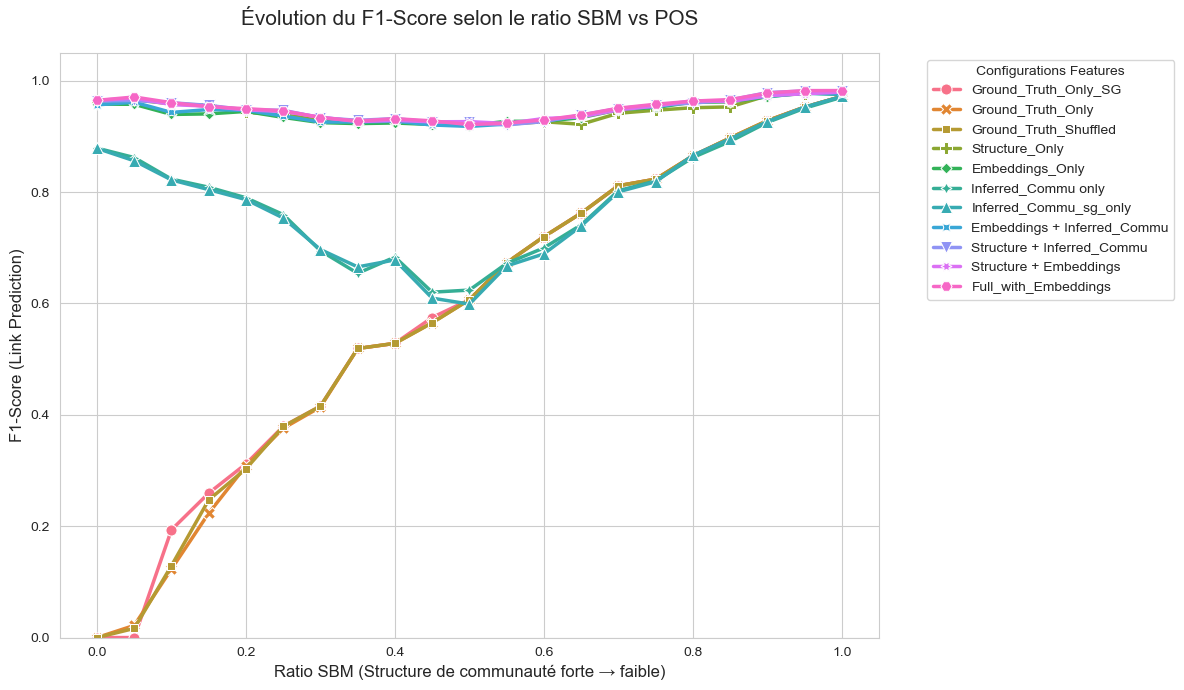

In [93]:
def plot_f1_comparison(df_results, metric="F1-Score"):
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # Création du lineplot
    # On utilise 'Experiment' pour différencier les lignes par couleur et style
    ax = sns.lineplot(
        data=df_results, 
        x="Ratio_SBM", 
        y= metric, 
        hue="Experiment", 
        style="Experiment", 
        markers=True, 
        dashes=False,
        linewidth=2.5,
        markersize=8
    )
    
    # Personnalisation des axes
    plt.title(f"Évolution du {metric} selon le ratio SBM vs POS", fontsize=15, pad=20)
    plt.xlabel("Ratio SBM (Structure de communauté forte → faible)", fontsize=12)
    plt.ylabel(f"{metric} (Link Prediction)", fontsize=12)
    
    # Inversion de l'axe X si tu veux montrer la difficulté croissante
    # plt.gca().invert_xaxis() 
    
    plt.legend(title="Configurations Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 1.05) # Pour bien voir l'échelle de 0 à 1
    
    plt.tight_layout()

    output_dir = os.path.join("outputs", "plots")
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"artificial_graphs_comparaison_{metric}_per_SBM_ratio.png")
    
    # 3. La ligne magique
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Graphique sauvegardé ici : {save_path}")
    
    plt.show()

plot_f1_comparison(df_compare)

### 1.2 Exploration visuelle des positions et catégories

In [77]:
import matplotlib.pyplot as plt
import networkx as nx
import os

def plot_node_spatial_with_edges(G, title="Focus Liaisons Internes", selected_blocks=None):
    """
    Affiche les nœuds et les arêtes internes des blocs sélectionnés.
    """
    pos = nx.get_node_attributes(G, 'pos')
    blocks = nx.get_node_attributes(G, 'block')
    
    if not pos or not blocks:
        print("❌ Erreur : 'pos' ou 'block' manquants.")
        return

    plt.figure(figsize=(10, 10))
    
    # 1. Fond : tous les nœuds en gris
    all_nodes = list(G.nodes())
    nx.draw_networkx_nodes(G, pos, nodelist=all_nodes, node_color='lightgray', 
                           node_size=10, alpha=0.2)

    # 2. Sélection des nœuds et arêtes à mettre en avant
    if selected_blocks:
        target_nodes = [n for n, b in blocks.items() if b in selected_blocks]
        # On ne garde que les arêtes dont les DEUX extrémités sont dans les blocs sélectionnés
        target_edges = [(u, v) for u, v in G.edges() if u in target_nodes and v in target_nodes]
        
        # 3. Dessin des arêtes internes (le signal SBM)
        nx.draw_networkx_edges(G, pos, edgelist=target_edges, edge_color='blue', 
                               width=0.5, alpha=0.4)
        
        # 4. Dessin des nœuds sélectionnés (colorés par bloc)
        node_colors = [blocks[n] for n in target_nodes]
        scatter = nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, 
                                         node_color=node_colors, cmap='tab10', 
                                         node_size=40, edgecolors='black', linewidths=0.5)
        
        if len(selected_blocks) > 1:
            plt.colorbar(scatter, label="ID du Bloc")
    
    plt.title(title)
    plt.axis('off') # On enlève les axes pour mieux voir la structure
    
    # Sauvegarde
    plot_dir = os.path.join(PROJECT_ROOT, "outputs", "plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"{title.replace(' ', '_')}.png"), dpi=300)
    
    plt.show()

# --- TEST ---
# Essaye avec 2 blocs qui ont des scores F1 élevés
# plot_node_spatial_with_edges(G, selected_blocks=[1, 2], title="Structure Interne Blocs 1 et 2")

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Graphe chargé : 1000 nœuds et 3500 liens.


/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


NameError: name 'PROJECT_ROOT' is not defined

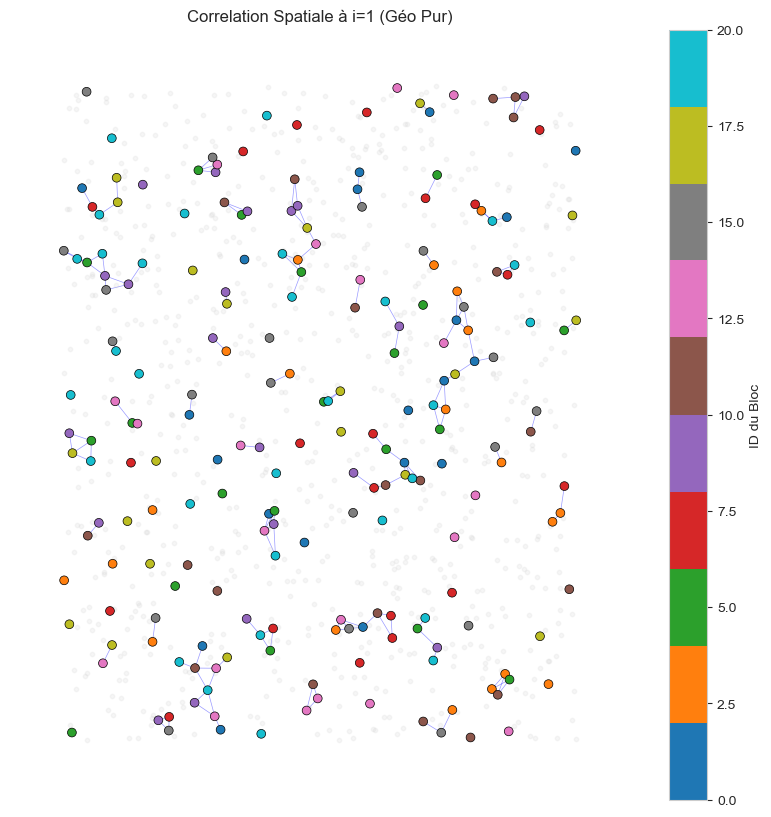

In [81]:
G_name = f"artificial_graph_sbm_1_00_pos_0_00"
dataset, _, _, _ = gp.load_all_data_for_graph(G_name)
G = load_json(f"graph_library/{G_name}.json")
plot_node_spatial_with_edges(G, title="Correlation Spatiale à i=1 (Géo Pur)", selected_blocks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])

### 1.3 Evaluation perfs sur echantillon plus large

In [79]:
def generate_extended_eval_data(G, initial_pairs_df, expansion_factor=50, concat = True):
    nodes_list = list(G.nodes())
    num_initial = len(initial_pairs_df)
    target_extra = num_initial * expansion_factor

    existing_pairs = set()
    for u, v in zip(initial_pairs_df['u'], initial_pairs_df['v']):
        existing_pairs.add(tuple(sorted((u, v))))

    extra_pairs_list = []
    current_extra_set = set() 
    
    while len(extra_pairs_list) < target_extra:
        batch_size = min(target_extra - len(extra_pairs_list), 50000)
        random_u = np.random.choice(nodes_list, size=batch_size)
        random_v = np.random.choice(nodes_list, size=batch_size)
        
        for u, v in zip(random_u, random_v):
            if u == v:
                continue
            
            pair = tuple(sorted((u, v)))
            
            if pair not in existing_pairs and pair not in current_extra_set:
                current_extra_set.add(pair)
                extra_pairs_list.append({'u': u, 'v': v, 'target': 0})
            
            if len(extra_pairs_list) >= target_extra:
                break

    extra_df = pd.DataFrame(extra_pairs_list)
    
    if concat: 
        full_df = pd.concat([initial_pairs_df, extra_df], ignore_index=True)
    else:
        full_df = extra_df

    full_df = add_ground_truth_groups(full_df, G)
    
    return full_df

def run_scaling_evaluation(G, base_dataset, experiments_dict, eval_data, factors=[10, 20, 30, 40, 50]):
    all_results = []
    
    for factor in factors:
        print(f"\n" + "="*50)
        print(f" TEST AVEC EXPANSION FACTOR : {factor}")
        print("="*50)
        
        # 1. Génération du dataset d'entraînement étendu
        extended_train_data = generate_extended_eval_data(G, base_dataset, expansion_factor=factor, concat=True)
        
        for exp_name, feat_list in experiments_dict.items():
            print(f"\n🔹 Expérience : {exp_name}")
            
            # 3. Entraînement et Test classique (sur le set étendu)
            stats_train, model, X_test_base, _, y_test_base, _ = gp.train_and_eval_xgboost(extended_train_data, features=feat_list)
            
            # 4. Evaluation
            X_eval_robust = pd.concat([eval_data[feat_list], X_test_base[feat_list]], ignore_index=True)
            y_eval_robust = pd.concat([eval_data["target"], y_test_base], ignore_index=True)
            
            eval_stats = gp.evaluate_model_performance(model, X_eval_robust, y_eval_robust)
            
            # 5. Stockage des résultats
            all_results.append({
                "Factor": factor,
                "Experiment": exp_name,
                "AUC-PR_Test": stats_train["AUC-PR"].iloc[0],
                "AUC-ROC_Eval": eval_stats["AUC-ROC"].iloc[0],
                "F1_Eval": eval_stats["F1-Score"].iloc[0]
            })
            
    return pd.DataFrame(all_results)

In [80]:
G_name = "artificial_graph_sbm_0_00_pos_1_00"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

dataset = dataset_raw[["u", "v", "target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_stress_test = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

experiments = {
    "Ground_Truth_Only_SG": ['same_group'],
    "Ground_Truth_Full": ['group_u', 'group_v', 'same_group'],
}

print(f"Lancement de l'évaluation multi-expériences...")
df_final_results = run_scaling_evaluation(
    G=G, 
    base_dataset=dataset, 
    experiments_dict=experiments, 
    eval_data=eval_stress_test, 
    factors= [0, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
)

print("\n Analyse terminée.")
print(df_final_results)

output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"ANALYSE_Scaling_Full_{G_name}.csv")
df_final_results.to_csv(save_path, index=False)
print(f"Résultats sauvegardés sous : {save_path}")

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3500 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib

--- TEST AVEC EXPANSION FACTOR : 0 ---
Modèle A (Same Group Only)...

 RÉSULTATS
[{'F1-Score': 0.9843304843304843, 'AUC-ROC': 0.9844839235811291, 'AP': 0.9833514976974892, 'AUC-PR': 0.9916351580908542}]

 RÉ

In [67]:
import os

# 1. Création du dossier de destination s'il n'existe pas
output_dir = "outputs/results"
os.makedirs(output_dir, exist_ok=True)

# 2. Définition du nom du fichier
file_name = f"ANALYSE_EtudeFacteurRatioLiensNonLiens_{G_name}.csv"
file_path = os.path.join(output_dir, file_name)

# 3. Sauvegarde du DataFrame
df_final_results.to_csv(file_path, index=False)

print(f"✅ Dataset sauvegardé avec succès dans : {file_path}")

✅ Dataset sauvegardé avec succès dans : outputs/results/ANALYSE_EtudeFacteurRatioLiensNonLiens_artificial_graph_sbm_1_00_pos_0_00.csv


In [37]:
G_name = "artificial_graph_sbm_0_60_pos_0_40"
G = load_json(f"graph_library/{G_name}.json")
dataset_raw, _, _, _ = gp.load_all_data_for_graph(G_name)

features_ground_truth = ['group_u', 'group_v','same_group']
features_ground_truth_sg = ['same_group']

dataset = dataset_raw[["u", "v","target"]]
dataset = add_ground_truth_groups(dataset, G)
eval_dataset = generate_extended_eval_data(G, dataset, expansion_factor=50, concat=False)

dataset_extended_50 = generate_extended_eval_data(G, df_initial, expansion_factor=50, concat=False)
dataset_extended_10 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)
dataset_extended_20 = generate_extended_eval_data(G, df_initial, expansion_factor=10, concat=False)

results =[]
print("DATASET DE BASE, SAME_GROUP ONLY : ")
stats_df, model_a, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth_sg)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })
X_eval = pd.concat([eval_dataset[features_ground_truth_sg], X_test[features_ground_truth_sg]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_a,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, SAME_GROUP ONLY - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET DE BASE, W GROUPS ID : ")
stats_df, model_b, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

X_eval = pd.concat([eval_dataset[features_ground_truth], X_test[features_ground_truth]], ignore_index=True)
y_eval = pd.concat([eval_dataset["target"], y_test], ignore_index=True)
gp.evaluate_model_performance(model_b,X_eval,y_eval)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID - EVALUATION",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

print("DATASET EXTENDED*50, W GROUPS ID : ")
stats_df, model_c, X_test, _, y_test, _ = gp.train_and_eval_xgboost(dataset_e, features=features_ground_truth)
results.append({
            "Experiment": "DATASET DE BASE, W GROUPS ID",
            "F1-Score": stats_df["F1-Score"].iloc[0]
        })

"""
gp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])
"""

/Users/bgdu69/miniconda3/envs/stageM2/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['group_u'] = df['u'].map(true_partition)
/var/folders/c1/t05kmpw95cg2nqvcvcdvhd200000gn/T/ipykernel_2734/1463293078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Graphe chargé : 1000 nœuds et 3495 liens.
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_60_pos_0_40
 Taille : 6990 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_60_pos_0_40.joblib
DATASET DE BASE, SAME_GROUP ONLY : 

 RÉSULTATS
[{'F1-Score': 0.5784313725490197, 'AUC-ROC': 0.7020746938976217, 'AP': 0.7099103007031315, 'AUC-PR': 0.8519782405744738}]

 RÉSULTATS D'ÉVALUATION
-------------

'\ngp.evaluate_model_performance(model_a,eval_dataset.drop(["target","u","v"]),eval_dataset[["target"]])\n'

### 1.4 - Exploration des Shap values

In [101]:
all_summaries = []

for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, _, shap_explainer, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']

    vals = shap_explainer.values
    
    if isinstance(vals, list):
        vals = vals[1]

    df_shap = pd.DataFrame(vals, columns=X_test.columns)
    mean_shap = df_shap.mean()
    mean_abs_shap = df_shap.abs().mean()
    
    summary = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap': mean_shap.values,
        'mean_abs_shap': mean_abs_shap.values,
        'sbm_param': i
    })
    all_summaries.append(summary)

df_final_results = pd.concat(all_summaries)


 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 38500 lignes, 29 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_05_pos_0_95
 Taille : 38500 lignes, 29 colonnes.
Objet chargé avec succès depui

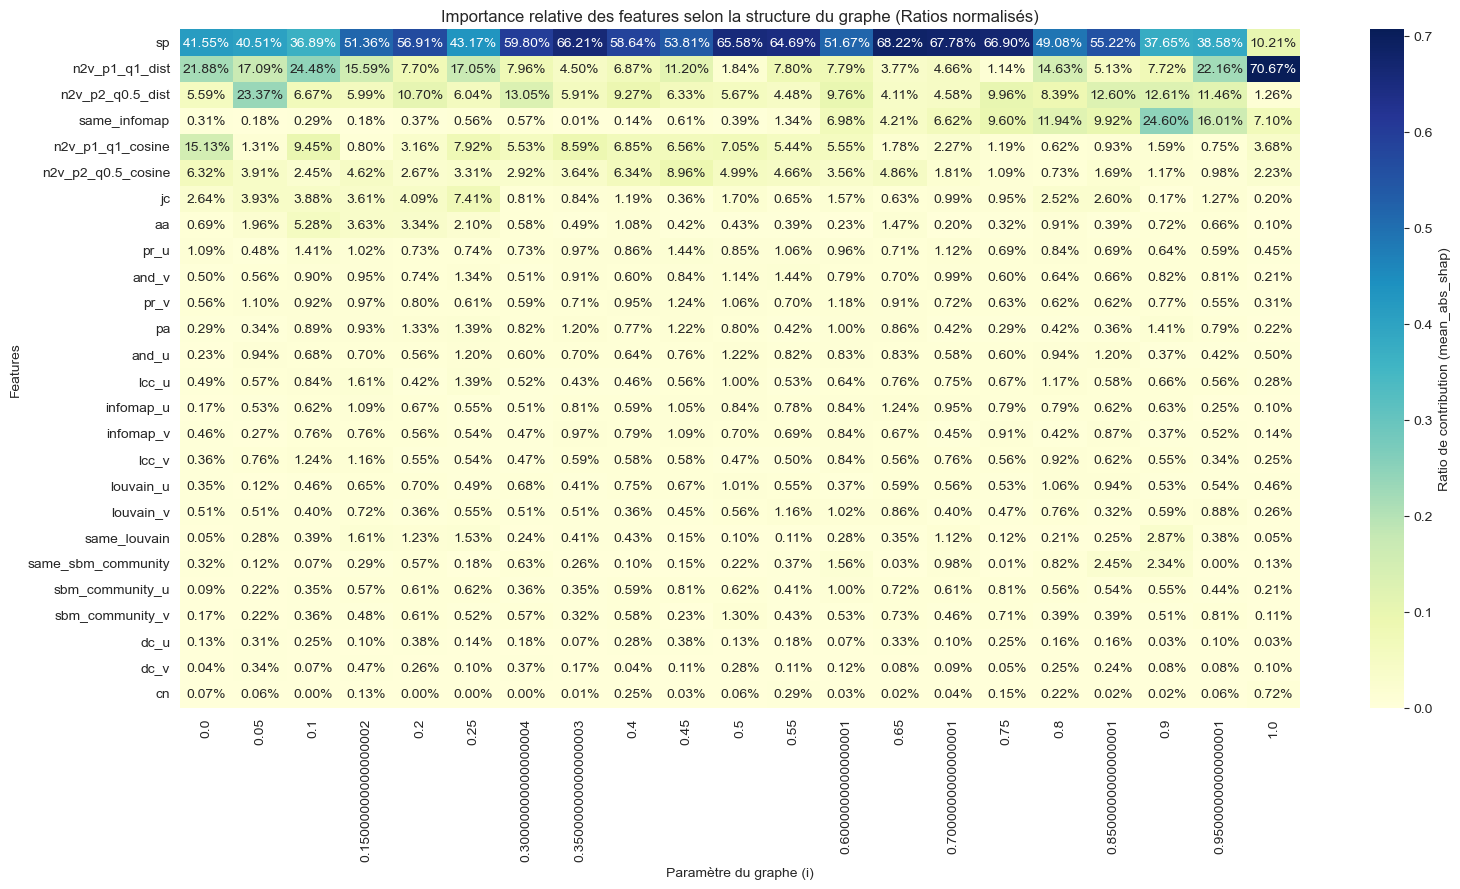

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 38500 lignes, 29 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_05_pos_0_95
 Taille : 38500 lignes, 29 colonnes.
Objet chargé avec succès depui

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance_evolution(df_results, metric="mean_abs_shap", as_ratio=True):
    """
    Génère une heatmap montrant l'évolution de l'importance des features.
    """
    heatmap_data = df_results.pivot(index='feature', columns='sbm_param', values=metric)
    
    if as_ratio:
        heatmap_data = heatmap_data.div(heatmap_data.sum(axis=0), axis=1)
        label_name = f"Ratio de contribution ({metric})"
        fmt_type = ".2%"
    else:
        label_name = f"Valeur brute ({metric})"
        fmt_type = ".3f"

    heatmap_data['avg_importance'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values(by='avg_importance', ascending=False).drop(columns='avg_importance')

    plt.figure(figsize=(16, 9))
    sns.heatmap(heatmap_data, 
                annot=True,       
                fmt=fmt_type,        
                cmap="YlGnBu",    
                cbar_kws={'label': label_name})

    title_suffix = "(Ratios normalisés)" if as_ratio else "(Valeurs brutes)"
    plt.title(f"Importance relative des features selon la structure du graphe {title_suffix}")
    plt.xlabel("Paramètre du graphe (i)")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

plot_feature_importance_evolution(df_final_results, as_ratio=True)


all_distribs = []
for i in np.arange(0, 1.05, 0.05):
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    _, xgboost_data, _, _ = gp.load_all_data_for_graph(G_name)
    X_test = xgboost_data['X_test']
    y_test = xgboost_data['y_test']
    
    pos_sp = X_test[y_test == 1]['sp'].value_counts(normalize=True).to_dict()
    neg_sp = X_test[y_test == 0]['sp'].value_counts(normalize=True).to_dict()
    
    row = {'sbm_param': round(i, 2)}
    for dist in range(1, 7):
        row[f'pos_sp_{dist}'] = pos_sp.get(dist, 0)
        row[f'neg_sp_{dist}'] = neg_sp.get(dist, 0)
    
    row['pos_sp_7+'] = sum(v for k, v in pos_sp.items() if k >= 7 or k == 0)
    row['neg_sp_7+'] = sum(v for k, v in neg_sp.items() if k >= 7 or k == 0)
    
    all_distribs.append(row)

df_sp_detailed = pd.DataFrame(all_distribs)

cols = ['sbm_param'] + [f'{prefix}_sp_{d}' for d in list(range(1, 7)) + ['7+'] for prefix in ['pos', 'neg']]
df_sp_detailed = df_sp_detailed[cols]

pd.options.display.float_format = '{:.3f}'.format
print(df_sp_detailed.to_string(index=False))

## 2 - Other

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


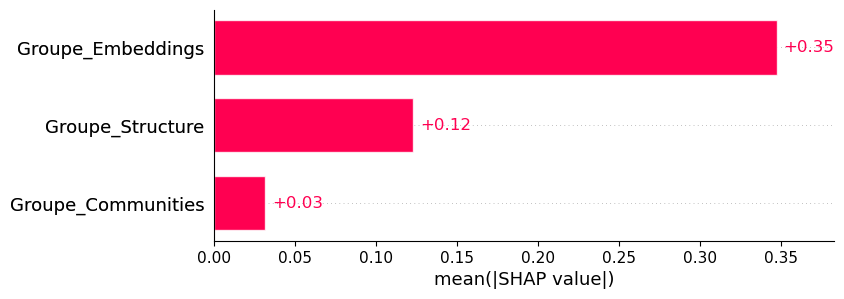


--- SHAP Bar Plot (Absolute) ---


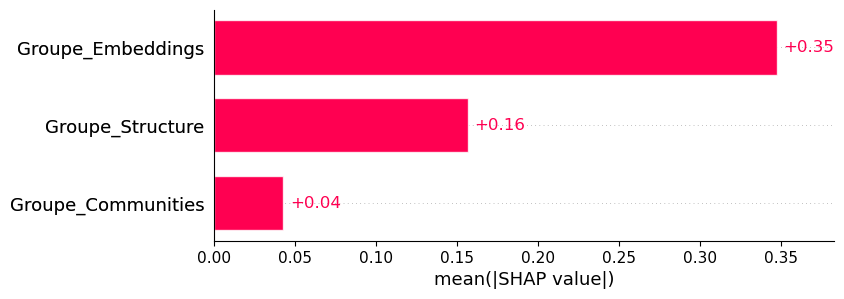


--- SHAP Custom Analysis ---


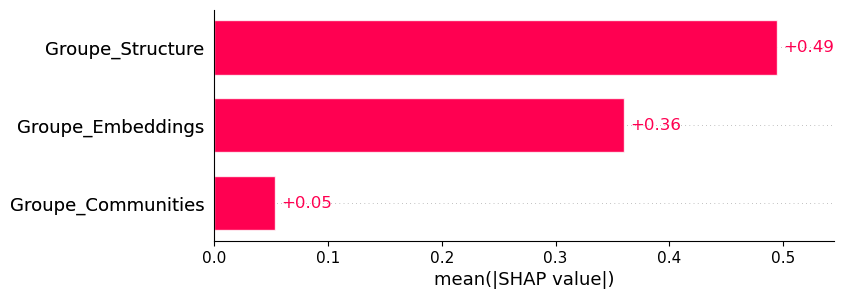


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


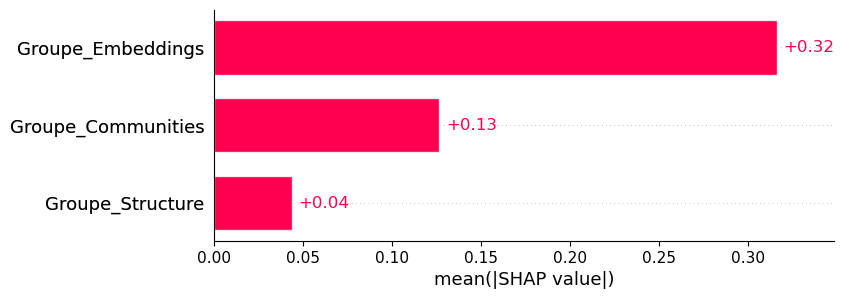


--- SHAP Bar Plot (Absolute) ---


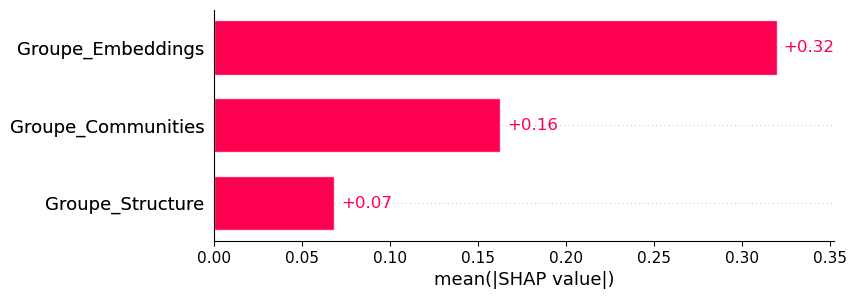


--- SHAP Custom Analysis ---


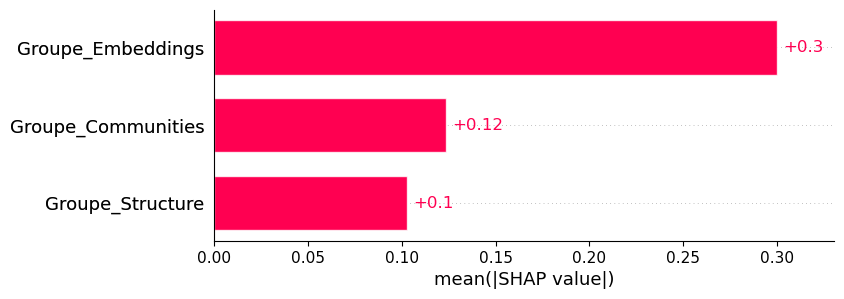


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
def xgboost_shap_pipeline(dataset, name):
    exclude = ['u', 'v', 'target', 'label']
    features = [col for col in dataset.columns if col not in exclude]
    
    results, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset, features=features)

    data_to_save = {
        "results": results,
        "model": model,
        "X_test": X_test,
        "X_train": X_train,
        "y_test": y_test,
        "y_train": y_train
    }

    print("Sauvegarde des données XGBoost (model,X1yTest et Train)")
    gp.loadsave_data_joblib(data=data_to_save,filename=f"xgboost_data_{name}.joblib", mode="save")

    print("\n RÉSULTATS")
    print(results.to_string(index=False))

    print("\n Shapley va ! Lu.")

    shap_explanation = gp.analyze_with_shap(model, X_test)
    print("Sauvegarde de l'analyse SHAP")
    gp.loadsave_data_joblib(data=shap_explanation, filename = f"shap_explainer_{name}.joblib", mode="save")

xgboost_shap_pipeline(dataset_sbm_1_true_groups, "TEST_W_REAL_GROUPS_SBM_1")
xgboost_shap_pipeline(dataset_sbm_0_5_true_groups, "TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_1.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_1.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_1:

--- SHAP Bar Plot (Signed) ---


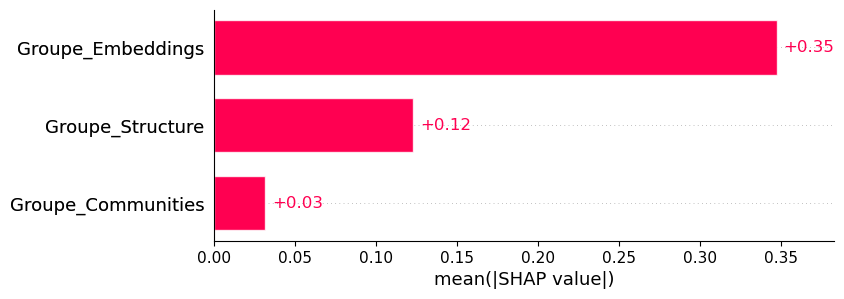


--- SHAP Bar Plot (Absolute) ---


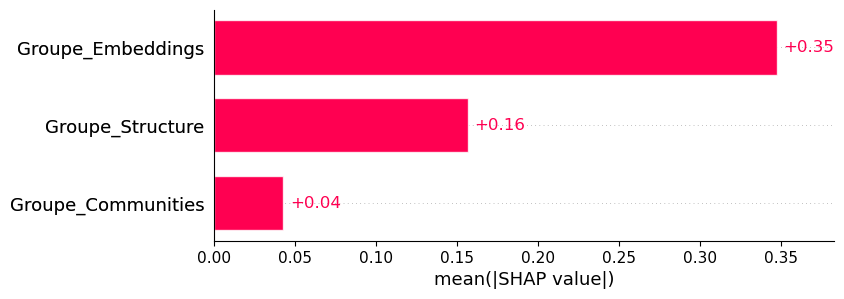


--- SHAP Custom Analysis ---


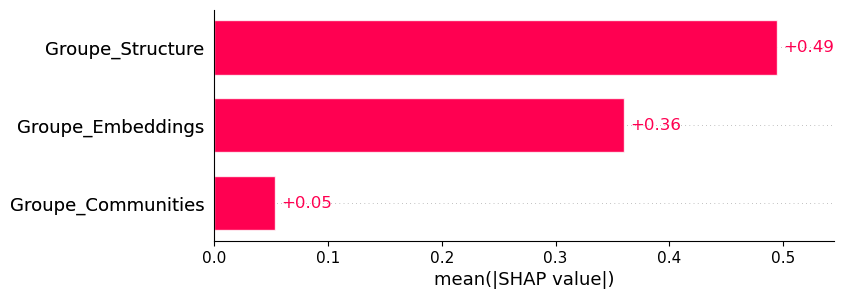


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.2118
Groupe_Communities        | 0.2504
Groupe_Embeddings         | 0.0024
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Custom SHAP baseline : general
Objet sauvegardé dans : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_TEST_W_REAL_GROUPS_SBM_0_5.joblib

Evaluation avec SHAP par groupe pour TEST_W_REAL_GROUPS_SBM_0_5:

--- SHAP Bar Plot (Signed) ---


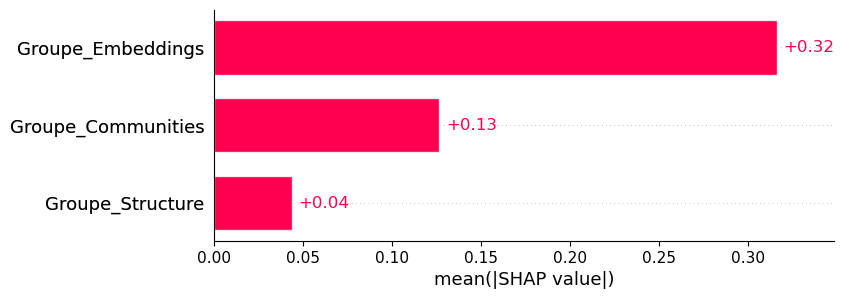


--- SHAP Bar Plot (Absolute) ---


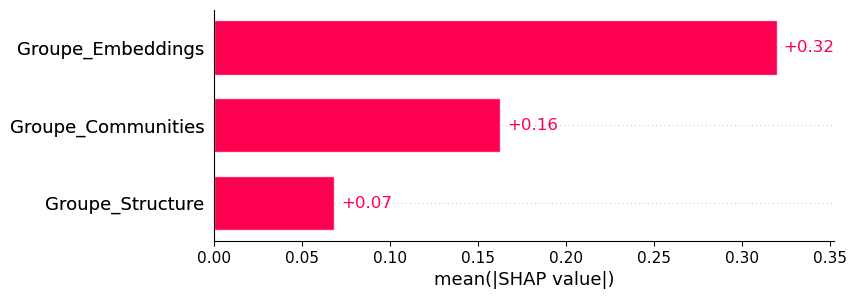


--- SHAP Custom Analysis ---


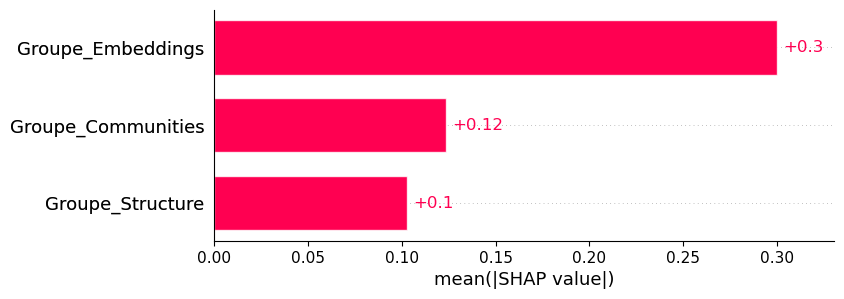


Catégorie                 | Contradiction Ratio 
--------------------------------------------------
Groupe_Structure          | 0.3363
Groupe_Communities        | 0.2872
Groupe_Embeddings         | 0.0228


{'G_name': 'TEST_W_REAL_GROUPS_SBM_0_5',
 'groupes': {'Groupe_Structure': ['cn',
   'aa',
   'jc',
   'pa',
   'sp',
   'pr_u',
   'pr_v',
   'lcc_u',
   'lcc_v',
   'and_u',
   'and_v',
   'dc_u',
   'dc_v'],
  'Groupe_Communities': ['group_u', 'group_v', 'same_group'],
  'Groupe_Embeddings': ['n2v_p2_q0.5_cosine',
   'n2v_p2_q0.5_dist',
   'n2v_p1_q1_cosine',
   'n2v_p1_q1_dist']},
 'mean_contradiction_ratios': array([0.33627087, 0.28716376, 0.02282715]),
 'shap_explanation_grouped': .values =
 array([[-0.04501853, -0.23169398, -0.28003966],
        [-0.05545718, -0.09288427, -0.38451566],
        [-0.05905618, -0.09242303, -0.4020008 ],
        ...,
        [ 0.02315003,  0.19894455,  0.21765491],
        [-0.05401293, -0.21809359, -0.28687188],
        [ 0.0277092 ,  0.04102151,  0.3712122 ]])
 
 .base_values =
 array([0.55978833, 0.55978833, 0.55978833, ..., 0.55978833, 0.55978833,
        0.55978833]),
 'shap_explanation_abs': .values =
 array([[0.06101293, 0.23169398, 0.28003966

In [4]:
gp.evaluate("TEST_W_REAL_GROUPS_SBM_1", display = True)
gp.evaluate("TEST_W_REAL_GROUPS_SBM_0_5", display = True)

In [4]:
gp.display_shap("TEST_W_REAL_GROUPS_SBM_1")
gp.display_shap("TEST_W_REAL_GROUPS_SBM_0_5")

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_1.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib


1

In [30]:
dataset, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph("TEST_W_REAL_GROUPS_SBM_0_5")
dataset_base, xgboost_data_base, shap_explainer_base, shap_analysis_base = gp.load_all_data_for_graph("artificial_graph_sbm_0_50_pos_0_50")

gp.evaluate_model_performance(model = xgboost_data["model"], X_test = xgboost_data["X_test"], y_test = xgboost_data["y_test"], plot = False)
gp.evaluate_model_performance(model = xgboost_data_base["model"], X_test = xgboost_data_base["X_test"], y_test = xgboost_data_base["y_test"], plot = False)

print(dataset.head(2))
print(dataset_base.head(2))


dataset_cleared = dataset.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)
dataset_base_cleared = dataset_base.drop(["n2v_p2_q0.5_cosine", "n2v_p2_q0.5_dist", "n2v_p1_q1_cosine", "n2v_p1_q1_dist"], axis = 1)

print(dataset_cleared.head(2))
print(dataset_base_cleared.head(2))


all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_cleared)
all_stats, model, X_test, X_train, y_test, y_train = gp.train_and_eval_xgboost(dataset_base)

 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_TEST_W_REAL_GROUPS_SBM_0_5
 Taille : 6988 lignes, 23 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_TEST_W_REAL_GROUPS_SBM_0_5.joblib
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_50_pos_0_50
 Taille : 6988 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hacker

In [43]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

all_results = []

for i in np.arange(0, 1.05, 0.05):
    
    sbm_val = f"{i:.2f}"
    pos_val = f"{1-i:.2f}"
    
    print(f"\n--- Évaluation : SBM {sbm_val} | POS {pos_val} ---")
    
    G_name = f"artificial_graph_sbm_{sbm_val.replace('.', '_')}_pos_{pos_val.replace('.', '_')}"
    
    dataset, _, _, _ = gp.load_all_data_for_graph(G_name)

    print(dataset.columns)

    stats_df = gp.evaluate_model_performance(model=xgboost_data["model"], X_test=xgboost_data["X_test"], y_test=xgboost_data["y_test"], plot=False)
    
    all_results.append({
        "Graph_Name": G_name,
        "SBM_Ratio": i,
        "F1-Score": stats_df["F1-Score"].iloc[0]
    })

df_final_results = pd.DataFrame(all_results)

print("\n--- TABLEAU RÉCAPITULATIF ---")
print(df_final_results)

output_dir = os.path.join("outputs", "plots")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "artificial_graphs_recapitulatif_performances_f1.csv")

df_final_results.to_csv(output_path, index=False)

print(f"\n Tableau récapitulatif sauvegardé ici : {output_path}")


--- Évaluation : SBM 0.00 | POS 1.00 ---
 Dataset chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00
 Taille : 7000 lignes, 26 colonnes.
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_0_00_pos_1_00.joblib
Index(['u', 'v', 'target', 'cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v',
       'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v', 'community_u',
       'community_v', 'same_community', 'infomap_u', 'infomap